# 03 — Clustering (K-Means)

**Input:** `data/processed/processed_data.csv`  
**Output:** `data/processed/clustered_data.csv`, `models/kmeans_model.pkl`

> See `rough.py` for scratch/experimental clustering code.


Group similar data points
 Discover hidden patterns
 Create segments (e.g., customer groups)


In [1]:
import pandas as pd

df = pd.read_csv('../data/processed/processed_data.csv')
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,0.909164,-1.188863,-1.284623,-1.282164,0.803692,-0.481917,-0.736833,0.750909,-0.807837
1,-1.099912,0.841140,-0.327151,0.779931,-0.336418,NaN,0.612411,0.097875,-0.807837
2,-1.099912,0.841140,1.408268,0.779931,-0.336418,-0.481917,-0.736833,-1.208193,0.577566
3,0.909164,0.841140,1.408268,0.779931,1.563766,-0.775471,1.961655,-0.555159,0.577566
4,-1.099912,0.841140,-0.207467,0.779931,0.043619,NaN,1.961655,2.056976,0.577566


In [9]:
# fill missing numeric values
df = df.fillna(df.median())

In [10]:
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,0.909164,-1.188863,-1.284623,-1.282164,0.803692,-0.481917,-0.736833,0.750909,-0.807837
1,-1.099912,0.841140,-0.327151,0.779931,-0.336418,-0.481917,0.612411,0.097875,-0.807837
2,-1.099912,0.841140,1.408268,0.779931,-0.336418,-0.481917,-0.736833,-1.208193,0.577566
3,0.909164,0.841140,1.408268,0.779931,1.563766,-0.775471,1.961655,-0.555159,0.577566
4,-1.099912,0.841140,-0.207467,0.779931,0.043619,-0.481917,1.961655,2.056976,0.577566


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

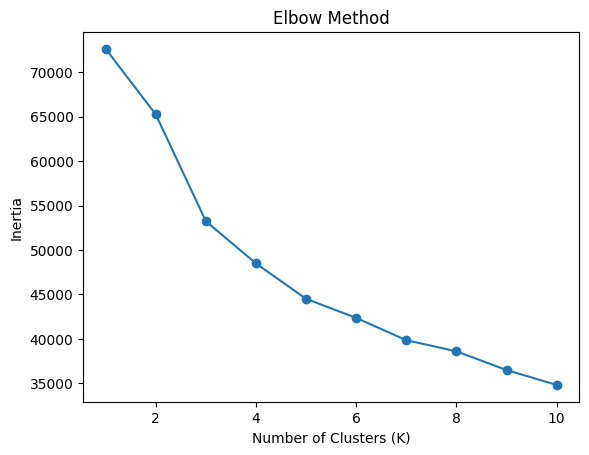

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(df_scaled)

In [14]:
print(df['Cluster'].value_counts())
print(df.groupby('Cluster').mean())

Cluster
2    3912
1    2693
0    1463
Name: count, dtype: int64
           Gender  Ever_Married       Age  Graduated  Profession  \
Cluster                                                            
0       -0.199055     -0.137091 -0.314962   0.230227   -0.181858   
1       -0.087540     -1.079561 -0.745578  -0.397752    0.241751   
2        0.134704      0.824535  0.631041   0.203262   -0.098410   

         Work_Experience  Spending_Score  Family_Size     Var_1  
Cluster                                                          
0               1.672686       -0.253577    -0.327512  0.124445  
1              -0.397328       -0.730821     0.274167 -0.206192  
2              -0.454152        0.597925    -0.057872  0.095402  


In [15]:
df.to_csv('../data/processed/clustered_data.csv', index=False)

print("Clustered data saved successfully!")

Clustered data saved successfully!
